In [ ]:
# A library for steerable CNNs.
!pip install e2cnn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.3/225.3 kB 3.8 MB/s eta 0:00:00


In [ ]:
import os
# I like to use typing, but you don't have to!
from typing import Any, Dict, Tuple, Union

import networkx as nx
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import shift
import scipy.sparse as sp
import tensorflow as tf
import tensorflow_datasets as tfds
import torch
from torch.utils.data import DataLoader
from torch import nn
from torch.nn import functional as F
from torch import optim
import torchvision
from torchvision import datasets, transforms
from e2cnn import gspaces
from e2cnn import nn as e2cnn_nn

# We might use tensorflow to load datasets.
# Prevent tensorflow from stealing our GPU.
tf.config.experimental.set_visible_devices([], "GPU")

# Interactive plots.
%matplotlib inline

In [ ]:
# Runtime -> Change runtime type -> Hardware accelerator -> GPU (-> Delete previous runtime -> OK).
if torch.cuda.is_available() and torch.cuda.device_count() > 0:
  print("PyTorch running on a GPU. Use '.to(device)' to move tensors and models to GPU.")
  device = torch.device("cuda:0")
else:
  print("WARNING: PyTorch running on a CPU. See comment above to request a GPU instance.")
  device = torch.device("cpu")

# Part 1: Training a convolutional network equivariant to discrete rotations. Testing on rotated MNIST.

We will continue with the MNIST dataset from Homework 1. Our goal is to design neural networks that can make good predictions about rotated versions of the MNIST characters when trained only on the original images. For this purpose, we will use original MNIST for training and rotated MNIST for validation.

## Data preprocessing

In [ ]:
# Download rotated MNIST.
!wget -nc http://www.iro.umontreal.ca/~lisa/icml2007data/mnist_rotation_new.zip
!unzip -n mnist_rotation_new.zip -d mnist_rotation_new

--2025-11-21 03:34:08--  http://www.iro.umontreal.ca/~lisa/icml2007data/mnist_rotation_new.zip
Resolving www.iro.umontreal.ca (www.iro.umontreal.ca)... 132.204.26.36
Connecting to www.iro.umontreal.ca (www.iro.umontreal.ca)|132.204.26.36|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 58424278 (56M) [application/zip]
Saving to: ‘mnist_rotation_new.zip’

mnist_rotation_new. 100%[===================>]  55.72M  30.6MB/s    in 1.8s    

2025-11-21 03:34:11 (30.6 MB/s) - ‘mnist_rotation_new.zip’ saved [58424278/58424278]

Archive:  mnist_rotation_new.zip
  inflating: mnist_rotation_new/mnist_all_rotation_normalized_float_train_valid.amat  
  inflating: mnist_rotation_new/mnist_all_rotation_normalized_float_test.amat  


In [ ]:
class MnistRotDataset(torch.utils.data.Dataset):

    def __init__(self, mode: str, transform=None):
        assert mode in ["train", "test"]

        if mode == "train":
            file = "mnist_rotation_new/mnist_all_rotation_normalized_float_train_valid.amat"
        else:
            file = "mnist_rotation_new/mnist_all_rotation_normalized_float_test.amat"

        self.transform = transform

        data = np.loadtxt(file, delimiter=" ")

        self.images = data[:, :-1].reshape(-1, 28, 28).astype(np.float32)
        self.labels = data[:, -1].astype(np.int64)
        self.num_samples = len(self.labels)

    def __getitem__(self, index: int):
        image, label = self.images[index], self.labels[index]
        image = Image.fromarray(image)
        if self.transform is not None:
            image = self.transform(image)
        return image, label

    def __len__(self) -> int:
        return len(self.labels)

In [ ]:
def prepare_mnist(batch_size: int) -> Tuple[DataLoader, DataLoader]:
  """Prepare MNIST training and evaluation data loaders in PyTorch.
  https://github.com/pytorch/examples/blob/main/mnist/main.py
  """
  t = transforms.ToTensor()

  train_ds = datasets.MNIST("/tmp/mnist", download=True, train=True, transform=t)
  eval_ds = datasets.MNIST("/tmp/mnist", download=True, train=False, transform=t)

  train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
  eval_loader = DataLoader(eval_ds, batch_size=batch_size, shuffle=False, num_workers=1)

  return train_loader, eval_loader

In [ ]:
def prepare_rotated_mnist(batch_size: int) -> Tuple[DataLoader, DataLoader]:
  """Prepare rotated MNIST training and evaluation data loaders in PyTorch.
  https://github.com/QUVA-Lab/e2cnn/blob/master/examples/model.ipynb
  """
  t = transforms.ToTensor()

  train_ds = MnistRotDataset("train", transform=t)
  eval_ds = MnistRotDataset("test", transform=t)

  train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
  eval_loader = DataLoader(eval_ds, batch_size=batch_size, shuffle=False, num_workers=1)

  return train_loader, eval_loader

### Original MNIST (train_loader, eval_loader)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 562kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.72MB/s]


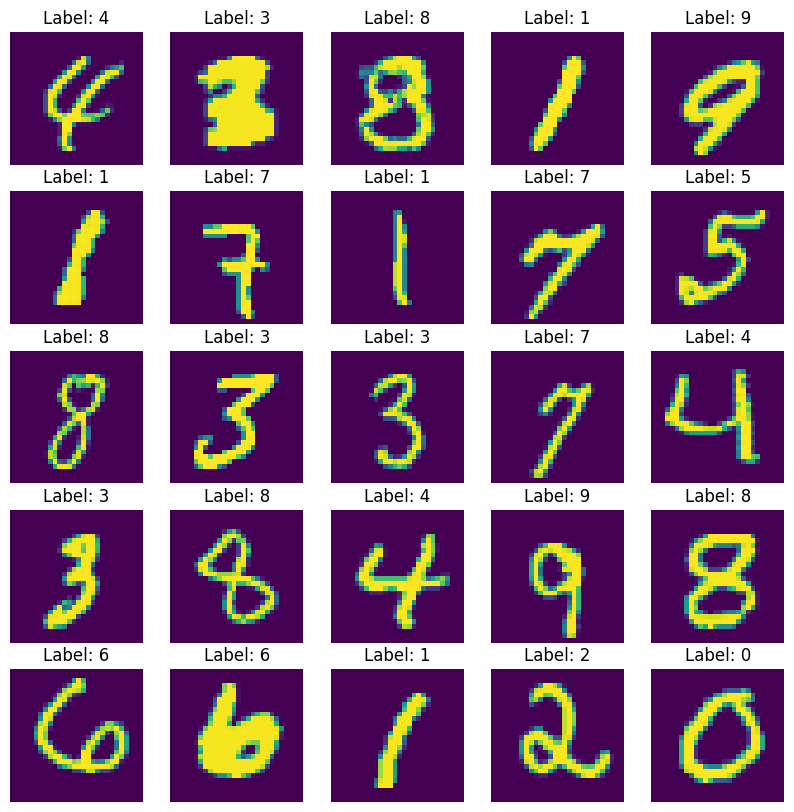

In [ ]:
train_loader, eval_loader = prepare_mnist(128)
example = next(iter(train_loader))
plt.figure(figsize=(10, 10))
for i in range(5*5):
  plt.subplot(5, 5, 1 + i)
  plt.title("Label: {:d}".format(example[1][i]))
  plt.imshow(example[0][i][0])
  plt.axis("off")

### Rotated MNIST (train_rot_loader, eval_rot_loader)

Note that this dataset contains continuous rotations and reflections of the original images.

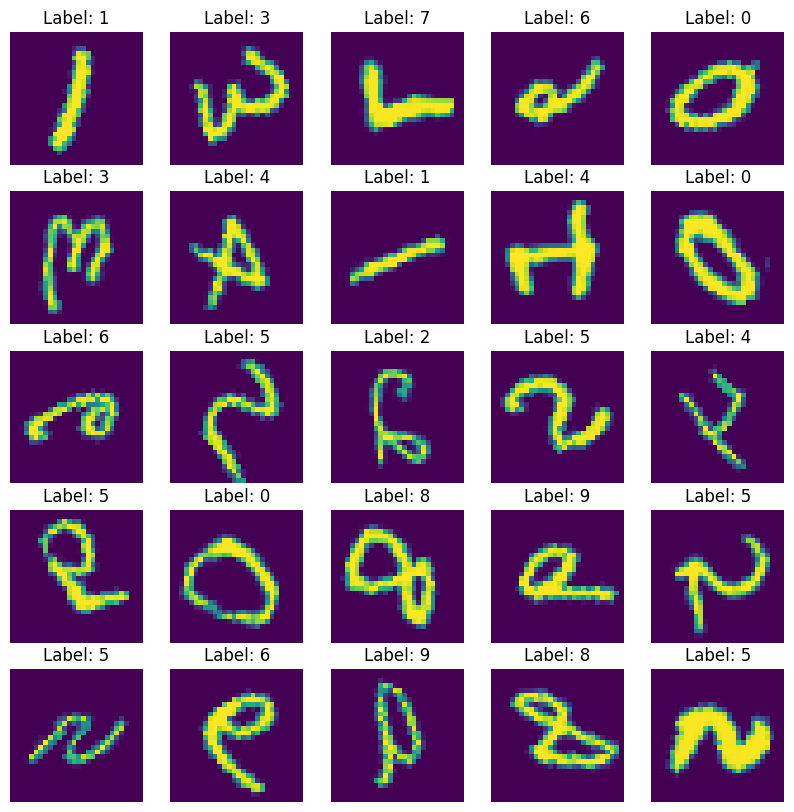

In [ ]:
train_rot_loader, eval_rot_loader = prepare_rotated_mnist(128)
example = next(iter(train_rot_loader))
plt.figure(figsize=(10, 10))
for i in range(5*5):
  plt.subplot(5, 5, 1 + i)
  plt.title("Label: {:d}".format(example[1][i]))
  plt.imshow(example[0][i][0])
  plt.axis("off")

## Training a baseline

In [ ]:
class CNNBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=(5,5), stride=(2,2), padding=(2,2))
        self.conv2 = nn.Conv2d(64, 64, kernel_size=(5,5), stride=(2,2), padding=(2,2))
        self.conv3 = nn.Conv2d(64, 64, kernel_size=(5,5), stride=(2,2),padding=(2,2))
        self.conv4 = nn.Conv2d(64, 64, kernel_size=(5,5), stride=(2,2),padding=(2,2))
        self.linear1 = nn.Linear(256, 128)
        self.linear2 = nn.Linear(128, 10)
        self.act = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.act(self.conv3(x))
        x = self.act(self.conv4(x))

        x = x.reshape(x.shape[0], -1)
        x = self.act(self.linear1(x))
        x = F.log_softmax(self.linear2(x), dim=-1)

        return x

In [ ]:
def train(train_loader: DataLoader, model: nn.Module,
          optimizer: optim.Optimizer, epochs: int):

  losses = []
  # 1 epoch = 1 pass through the dataset.
  for epoch in range(epochs):
    print("Epoch {:d} / {:d}".format(epoch, epochs))
    # train_loader steps once it iterates over all data.
    for train_step, batch in enumerate(train_loader):
      # train_loader gives us batched images (CxHxW) and labels (integers).
      # If we are using a GPU we need to move them to the device.
      inputs, labels = batch[0].to(device), batch[1].to(device)
      # Reset last optimization step.
      optimizer.zero_grad()
      # Make prediction, calculate loss.
      outputs = model(inputs)
      loss = F.nll_loss(outputs, labels)
      # Compute gradients and update weights.
      loss.backward()
      optimizer.step()
      losses.append(loss.item())

      if train_step > 0 and train_step % 50 == 0:
        print("Mean of last 50 losses: {:f}".format(np.mean(losses[-50:])))

  plt.plot(losses)
  plt.xlabel("Training step")
  plt.ylabel("Loss")

In [ ]:
# We don't need gradients during evaluation.
@torch.no_grad()
def evaluate(eval_loader: DataLoader, model: nn.Module):

  accuracy = []

  for batch in eval_loader:
    inputs, labels = batch[0].to(device), batch[1].to(device)
    outputs = model(inputs)
    pred_labels = torch.argmax(outputs, dim=-1)
    tmp = (labels == pred_labels).float().mean()
    accuracy.append(tmp.item())

  # We compute the mean of means over batches.
  # This could be slightly skewed if the last batch is smaller.
  # Does not matter too much here.
  accuracy = np.mean(accuracy)
  print("Correct answer in {:.1f}% of cases.".format(accuracy * 100))

In [ ]:
@torch.no_grad()
def plot_predictions(eval_loader: DataLoader, model: nn.Module):
  example = next(iter(eval_loader))
  inputs = example[0].to(device)
  outputs = model(inputs)
  pred_labels = torch.argmax(outputs, dim=-1).to("cpu").numpy()

  plt.figure(figsize=(10, 10))
  for i in range(5*5):
    plt.subplot(5, 5, 1 + i)
    plt.title("Label: {:d}".format(pred_labels[i]))
    plt.imshow(example[0][i][0])
    plt.axis("off")

Epoch 0 / 5
Mean of last 50 losses: 1.051593
Mean of last 50 losses: 0.305794
Mean of last 50 losses: 0.207043
Mean of last 50 losses: 0.169196
Mean of last 50 losses: 0.151815
Mean of last 50 losses: 0.120918
Mean of last 50 losses: 0.104887
Mean of last 50 losses: 0.087557
Mean of last 50 losses: 0.092785
Epoch 1 / 5
Mean of last 50 losses: 0.072240
Mean of last 50 losses: 0.064119
Mean of last 50 losses: 0.074448
Mean of last 50 losses: 0.072791
Mean of last 50 losses: 0.061957
Mean of last 50 losses: 0.066476
Mean of last 50 losses: 0.059244
Mean of last 50 losses: 0.050334
Mean of last 50 losses: 0.062723
Epoch 2 / 5
Mean of last 50 losses: 0.048004
Mean of last 50 losses: 0.047442
Mean of last 50 losses: 0.046287
Mean of last 50 losses: 0.044544
Mean of last 50 losses: 0.050087
Mean of last 50 losses: 0.039322
Mean of last 50 losses: 0.036232
Mean of last 50 losses: 0.043388
Mean of last 50 losses: 0.039606
Epoch 3 / 5
Mean of last 50 losses: 0.028881
Mean of last 50 losses: 0.02

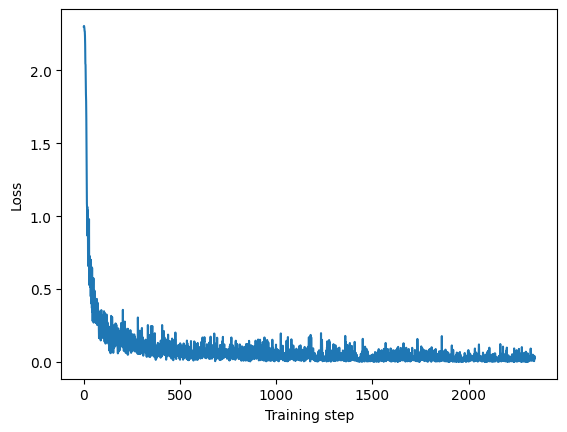

In [ ]:
model = CNNBaseline().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
train(train_loader, model, optimizer, 5)

### Evaluating on the original MNIST dataset

In [ ]:
evaluate(eval_loader, model)

Correct answer in 98.9% of cases.


### Evaluating on the rotated MNIST dataset (you should use this one)

In [ ]:
evaluate(eval_rot_loader, model)

Correct answer in 28.2% of cases.


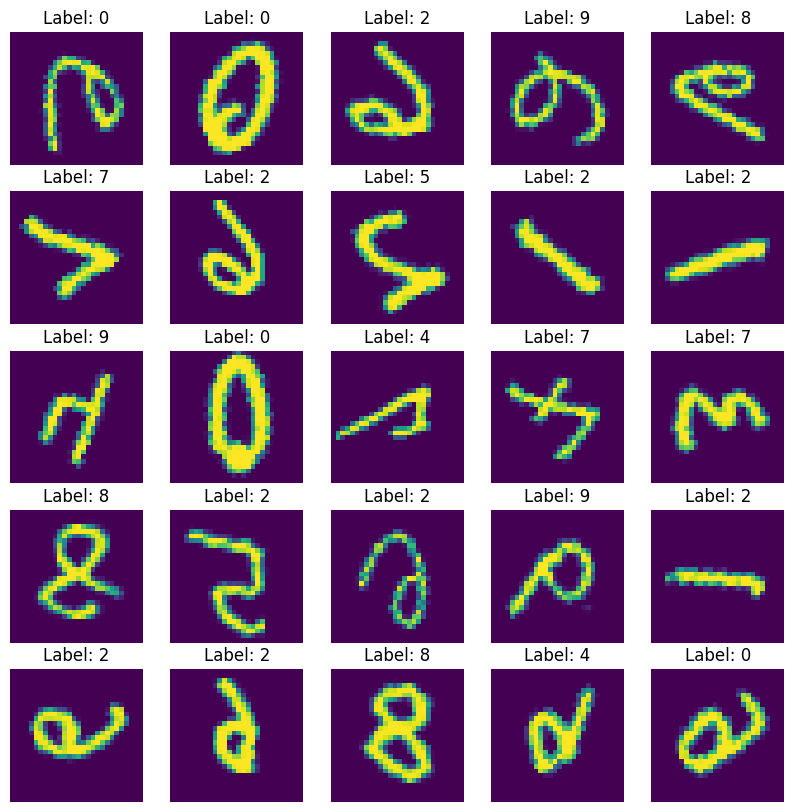

In [ ]:
plot_predictions(eval_rot_loader, model)

In [ ]:
from e2cnn import gspaces, nn as e2nn
import torch
import torch.nn as nn
import torch.nn.functional as F

class C4InvariantCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Define C4 symmetry group
        self.r2_act = gspaces.Rot2dOnR2(N=4)

        # Input: grayscale image (scalar field)
        feat_type_in = e2nn.FieldType(self.r2_act, [self.r2_act.trivial_repr])

        # Hidden layers: regular fields (64 regular fields)
        feat_type_hid_64 = e2nn.FieldType(self.r2_act, 64 * [self.r2_act.regular_repr])

        # Equivariant convolutional layers
        self.conv1 = e2nn.R2Conv(feat_type_in, feat_type_hid_64, kernel_size=5, padding=2, stride=2)
        self.bn1 = e2nn.InnerBatchNorm(feat_type_hid_64)
        self.relu1 = e2nn.ReLU(feat_type_hid_64)

        self.conv2 = e2nn.R2Conv(feat_type_hid_64, feat_type_hid_64, kernel_size=5, padding=2, stride=2)
        self.bn2 = e2nn.InnerBatchNorm(feat_type_hid_64)
        self.relu2 = e2nn.ReLU(feat_type_hid_64)

        self.conv3 = e2nn.R2Conv(feat_type_hid_64, feat_type_hid_64, kernel_size=5, padding=2, stride=2)
        self.bn3 = e2nn.InnerBatchNorm(feat_type_hid_64)
        self.relu3 = e2nn.ReLU(feat_type_hid_64)

        self.conv4 = e2nn.R2Conv(feat_type_hid_64, feat_type_hid_64, kernel_size=5, padding=2, stride=2)
        self.bn4 = e2nn.InnerBatchNorm(feat_type_hid_64)
        self.relu4 = e2nn.ReLU(feat_type_hid_64)

        # Pool to spatial 1x1 and make invariant
        self.pool = e2nn.PointwiseAvgPool(feat_type_hid_64, kernel_size=1)
        self.invariant_map = e2nn.GroupPooling(feat_type_hid_64)

        # After GroupPooling on 64 regular fields with C4: 64 * 4 = 256 features
        self.linear1 = nn.Linear(256, 128)
        self.linear2 = nn.Linear(128, 10)
        self.act = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Wrap input in GeometricTensor
        feat_type_in = e2nn.FieldType(self.r2_act, [self.r2_act.trivial_repr])
        x = e2nn.GeometricTensor(x, feat_type_in)

        # Equivariant convolutional blocks
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)

        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu4(x)

        # Pool to spatial 1x1
        x = self.pool(x)

        # Make invariant (removes group dimension)
        x = self.invariant_map(x)

        # Extract tensor and flatten
        # Shape: (batch_size, 256) after GroupPooling
        x = x.tensor.reshape(x.tensor.shape[0], -1)

        # Standard classification head
        x = self.act(self.linear1(x))
        x = F.log_softmax(self.linear2(x), dim=-1)

        return x

In [ ]:
from typing import Tuple
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch

def prepare_90_rotated_mnist(batch_size: int, rotation: int = 0) -> Tuple[DataLoader, DataLoader]:
    """Prepare MNIST training and evaluation data loaders in PyTorch.

    Args:
        batch_size: Batch size for data loaders
        rotation: Rotation to apply to images
                 0 = no rotation (0°)
                 1 = 90° rotation
                 2 = 180° rotation
                 3 = 270° rotation

    https://github.com/pytorch/examples/blob/main/mnist/main.py
    """

    # Map rotation parameter to degrees
    rotation_degrees = {
        0: 0,
        1: 90,
        2: 180,
        3: 270
    }

    if rotation not in rotation_degrees:
        raise ValueError("rotation must be 0, 1, 2, or 3")

    degrees = rotation_degrees[rotation]

    # Create transform pipeline
    transform_list = [transforms.ToTensor()]

    # Add rotation if needed
    if degrees > 0:
        transform_list.append(transforms.RandomRotation((degrees, degrees)))

    t = transforms.Compose(transform_list)

    train_ds = datasets.MNIST("/tmp/mnist", download=True, train=True, transform=t)
    eval_ds = datasets.MNIST("/tmp/mnist", download=True, train=False, transform=t)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
    eval_loader = DataLoader(eval_ds, batch_size=batch_size, shuffle=False, num_workers=1)

    return train_loader, eval_loader

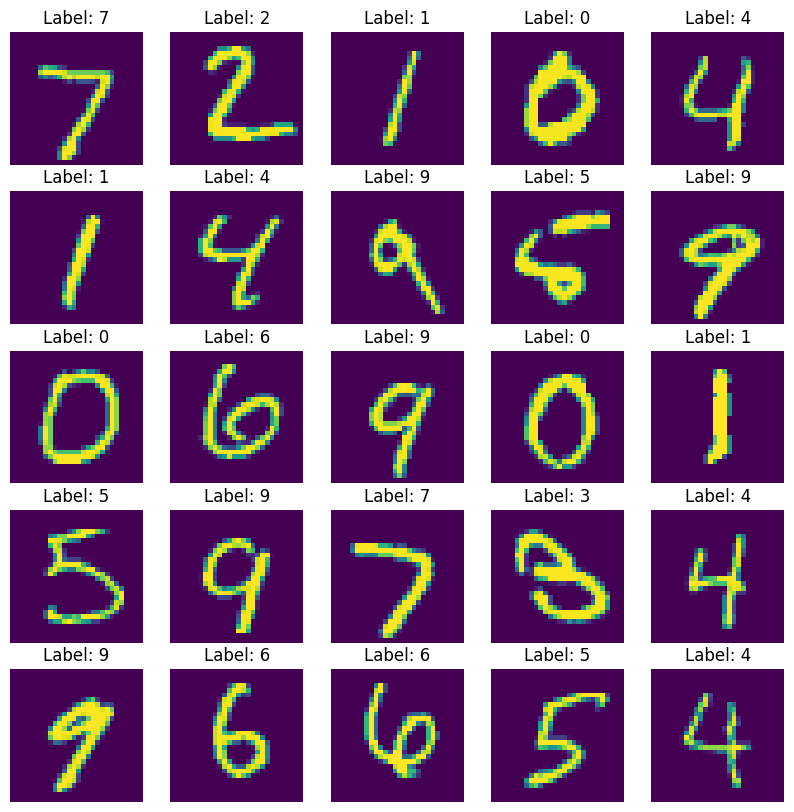

In [ ]:
train_0degree_loader, eval_0degree_loader = prepare_90_rotated_mnist(128,0)
example = next(iter(eval_0degree_loader))
plt.figure(figsize=(10, 10))
for i in range(5*5):
  plt.subplot(5, 5, 1 + i)
  plt.title("Label: {:d}".format(example[1][i]))
  plt.imshow(example[0][i][0])
  plt.axis("off")

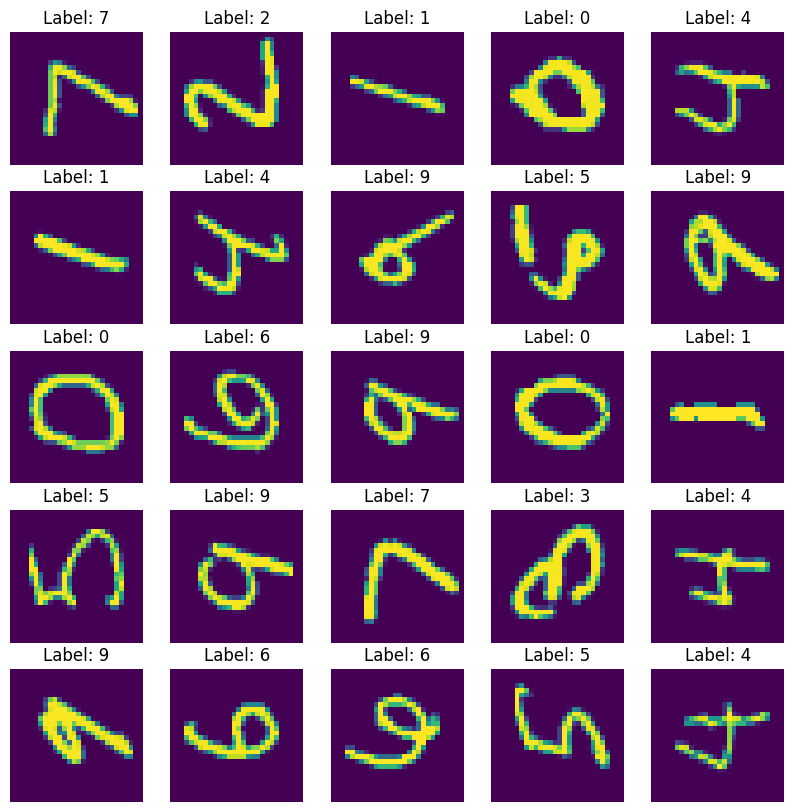

In [ ]:
train_90degree_loader, eval_90degree_loader = prepare_90_rotated_mnist(128,1)
example = next(iter(eval_90degree_loader))
plt.figure(figsize=(10, 10))
for i in range(5*5):
  plt.subplot(5, 5, 1 + i)
  plt.title("Label: {:d}".format(example[1][i]))
  plt.imshow(example[0][i][0])
  plt.axis("off")

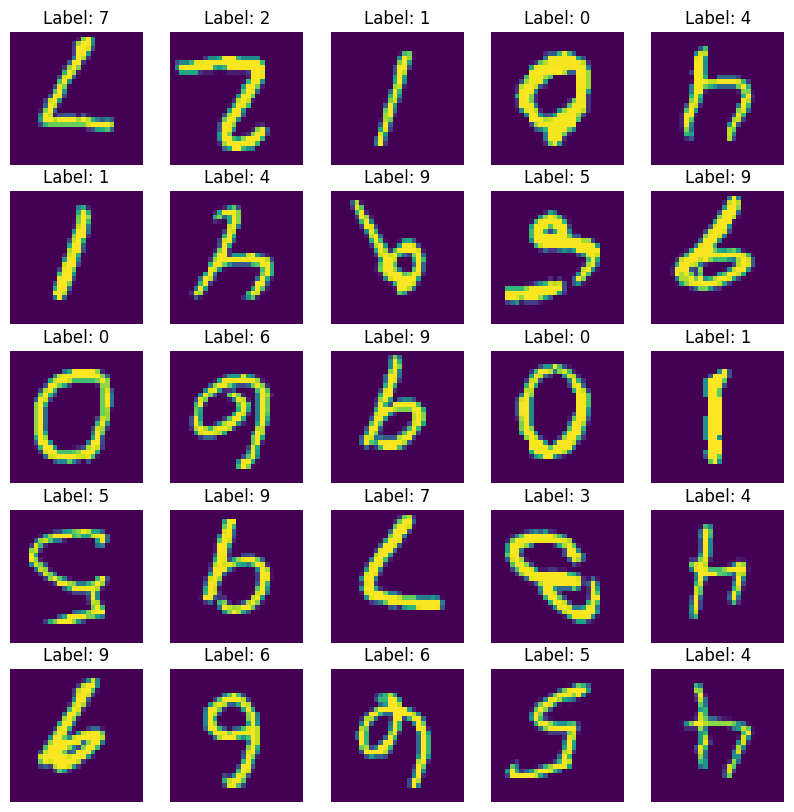

In [ ]:
train_180degree_loader, eval_180degree_loader = prepare_90_rotated_mnist(128,2)
example = next(iter(eval_180degree_loader))
plt.figure(figsize=(10, 10))
for i in range(5*5):
  plt.subplot(5, 5, 1 + i)
  plt.title("Label: {:d}".format(example[1][i]))
  plt.imshow(example[0][i][0])
  plt.axis("off")

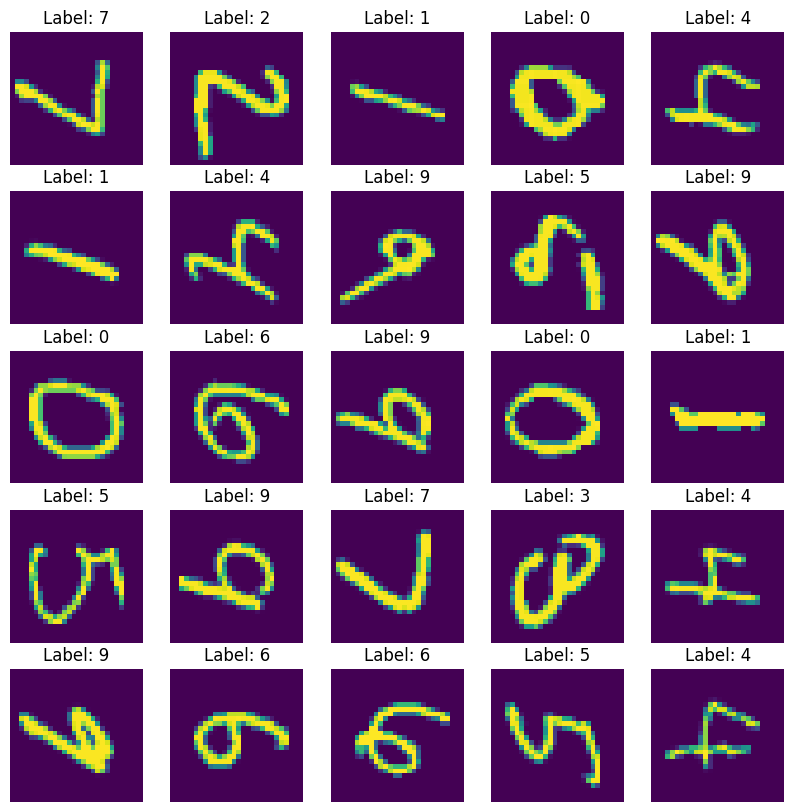

In [ ]:
train_270degree_loader, eval_270degree_loader = prepare_90_rotated_mnist(128,3)
example = next(iter(eval_270degree_loader))
plt.figure(figsize=(10, 10))
for i in range(5*5):
  plt.subplot(5, 5, 1 + i)
  plt.title("Label: {:d}".format(example[1][i]))
  plt.imshow(example[0][i][0])
  plt.axis("off")

## == Part 1 ==

Implementing a C4-invariant (cyclic group -- discrete rotations) convolutional network using the [e2cnn library](https://github.com/QUVA-Lab/e2cnn). (Reference tutorial [this tutorial](https://github.com/QUVA-Lab/e2cnn/blob/master/examples/introduction.ipynb)). Comparing baseline and C4-invarant convolutional networks when trained on MNIST and tested on rotated MNIST. Reporting learning curves (training step vs training loss) and validation accuracies.

In [ ]:
model_c4 = C4InvariantCNN().to(device)
optimizer = optim.Adam(model_c4.parameters(), lr=0.001)

/usr/local/lib/python3.12/dist-packages/e2cnn/nn/modules/r2_conv/basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:29.)
  full_mask[mask] = norms.to(torch.uint8)


In [ ]:
train(train_0degree_loader, model_c4, optimizer, 5)

Epoch 0 / 5


KeyboardInterrupt: 

In [ ]:
train(train_90degree_loader, model_c4, optimizer, 5)

In [ ]:
train(train_180degree_loader, model_c4, optimizer, 5)

In [ ]:
train(train_270degree_loader, model_c4, optimizer, 5)

In [ ]:
evaluate(eval_rot_loader, model_c4)

In [ ]:
evaluate(eval_rot_loader, model)


[**Part 2**] Ensuring that your C4-invariant convolutional network is invariant to 90 degree rotations of the input image. Testing the invarience.


In [ ]:
evaluate(eval_0degree_loader, model_c4)



In [ ]:
evaluate(eval_90degree_loader, model_c4)

In [ ]:
evaluate(eval_180degree_loader, model_c4)

In [ ]:
evaluate(eval_270degree_loader, model_c4)


[**Part 3**] Implementing D1, D2, D4, D8, C2 and C8 invariant convolutional networks and compare their validation accuracies on rotated MNIST to your C4-invariant convolutional network. Dn is the dihedral group (reflections and discrete rotations) and Cn is the cyclic group (discrete rotations). D1 represents reflections only.

In [ ]:
from e2cnn import gspaces, nn as e2nn
import torch
import torch.nn as nn
import torch.nn.functional as F

class EquivariantCNN(nn.Module):
    """
    Flexible equivariant CNN supporting Cyclic (Cn) and Dihedral (Dn) groups.

    Args:
        N: Order of the group (number of rotations)
           - D1: N=1, reflections=True (reflections only)
           - C2: N=2, reflections=False (90° rotations)
           - D2: N=2, reflections=True (90° rotations + reflections)
           - C4: N=4, reflections=False (90° rotations)
           - D4: N=4, reflections=True (90° rotations + reflections)
           - C8: N=8, reflections=False (45° rotations)
           - D8: N=8, reflections=True (45° rotations + reflections)

        reflections: Whether to include reflection symmetry (dihedral) or only rotations (cyclic)
        hidden_channels: Number of regular representation fields (default: 64)
    """

    def __init__(self, N=4, reflections=True, hidden_channels=64):
        super().__init__()

        self.N = N
        self.reflections = reflections
        self.hidden_channels = hidden_channels

        # Create the symmetry group
        if N == 1:
            # D1: only reflections
            if reflections:
                self.r2_act = gspaces.FlipRot2dOnR2(N=1, axis=0)
            else:
                raise ValueError("C1 (trivial group) not supported. Use N >= 2 or reflections=True for D1.")
        else:
            # Cn or Dn for N >= 2
            self.r2_act = gspaces.FlipRot2dOnR2(N=N, axis=0) if reflections else gspaces.Rot2dOnR2(N=N)

        # Feature types
        feat_type_in = e2nn.FieldType(self.r2_act, [self.r2_act.trivial_repr])
        feat_type_hid = e2nn.FieldType(self.r2_act, hidden_channels * [self.r2_act.regular_repr])
        feat_type_inv = e2nn.FieldType(self.r2_act, hidden_channels * [self.r2_act.trivial_repr])

        # Equivariant convolutional blocks
        self.conv1 = e2nn.R2Conv(feat_type_in, feat_type_hid, kernel_size=5, padding=2, stride=2)
        self.bn1 = e2nn.InnerBatchNorm(feat_type_hid)
        self.relu1 = e2nn.ReLU(feat_type_hid)

        self.conv2 = e2nn.R2Conv(feat_type_hid, feat_type_hid, kernel_size=5, padding=2, stride=2)
        self.bn2 = e2nn.InnerBatchNorm(feat_type_hid)
        self.relu2 = e2nn.ReLU(feat_type_hid)

        self.conv3 = e2nn.R2Conv(feat_type_hid, feat_type_hid, kernel_size=5, padding=2, stride=2)
        self.bn3 = e2nn.InnerBatchNorm(feat_type_hid)
        self.relu3 = e2nn.ReLU(feat_type_hid)

        self.conv4 = e2nn.R2Conv(feat_type_hid, feat_type_hid, kernel_size=5, padding=2, stride=2)
        self.bn4 = e2nn.InnerBatchNorm(feat_type_hid)
        self.relu4 = e2nn.ReLU(feat_type_hid)

        # Project to invariant representation (rotation/reflection invariant features)
        self.invariant_proj = e2nn.R2Conv(feat_type_hid, feat_type_inv, kernel_size=1, padding=0)
        self.bn_inv = e2nn.InnerBatchNorm(feat_type_inv)

        # Pool to spatial 1x1
        self.pool = e2nn.PointwiseAvgPool(feat_type_inv, kernel_size=1)

        # Classification head
        self.linear1 = nn.Linear(hidden_channels, 128)
        self.linear2 = nn.Linear(128, 10)
        self.act = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Wrap input in GeometricTensor
        feat_type_in = e2nn.FieldType(self.r2_act, [self.r2_act.trivial_repr])
        x = e2nn.GeometricTensor(x, feat_type_in)

        # Equivariant convolutional blocks
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)

        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu4(x)

        # Project to invariant representation
        x = self.invariant_proj(x)
        x = self.bn_inv(x)

        # Pool to spatial 1x1
        x = self.pool(x)

        # Extract tensor and flatten
        x = x.tensor.reshape(x.tensor.shape[0], -1)

        # Classification head
        x = self.act(self.linear1(x))
        x = F.log_softmax(self.linear2(x), dim=-1)

        return x

In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from typing import Tuple, Optional, List

def prepare_mnist(
    batch_size: int,
    rotation_order: int = 4,
    include_reflections: bool = True,
    augment_train: bool = True,
    data_dir: str = "/tmp/mnist"
) -> Tuple[DataLoader, DataLoader]:
    """
    Prepare MNIST training and evaluation data loaders with optional symmetry augmentation.

    Args:
        batch_size: Batch size for data loaders
        rotation_order: Number of discrete rotation steps (N in Cn/Dn groups)
                       - C2/D2: N=2 (180° rotations)
                       - C4/D4: N=4 (90° rotations)
                       - C8/D8: N=8 (45° rotations)
        include_reflections: Whether to include reflection augmentation (dihedral) or only rotations (cyclic)
        augment_train: Whether to apply augmentation to training data
        data_dir: Directory to download/load MNIST

    Returns:
        Tuple of (train_loader, eval_loader)
    """

    # Calculate rotation angle range
    max_rotation_angle = 360 / rotation_order

    # Build augmentation pipeline
    augmentations = [
        transforms.RandomRotation(degrees=max_rotation_angle, fill=0),
    ]

    if include_reflections:
        # Add random horizontal and vertical flips
        augmentations.extend([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
        ])

    # Training transforms: augmentation + convert to tensor
    if augment_train:
        train_transform = transforms.Compose(augmentations + [transforms.ToTensor()])
    else:
        train_transform = transforms.ToTensor()

    # Eval transforms: no augmentation
    eval_transform = transforms.ToTensor()

    # Load datasets
    train_ds = datasets.MNIST(
        data_dir,
        download=True,
        train=True,
        transform=train_transform
    )
    eval_ds = datasets.MNIST(
        data_dir,
        download=True,
        train=False,
        transform=eval_transform
    )

    # Create data loaders
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )
    eval_loader = DataLoader(
        eval_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=1,
        pin_memory=True
    )

    return train_loader, eval_loader

In [ ]:
# C4 (90° rotations, no reflections)
train_loader, eval_loader = prepare_mnist(128, include_reflections=False)
example = next(iter(train_loader))
plt.figure(figsize=(10, 10))
for i in range(5*5):
  plt.subplot(5, 5, 1 + i)
  plt.title("Label: {:d}".format(example[1][i]))
  plt.imshow(example[0][i][0])
  plt.axis("off")

# D8 (45° rotations + reflections)
train_loader, eval_loader = prepare_mnist(128, rotation_order=8)
example = next(iter(train_loader))
plt.figure(figsize=(10, 10))
for i in range(5*5):
  plt.subplot(5, 5, 1 + i)
  plt.title("Label: {:d}".format(example[1][i]))
  plt.imshow(example[0][i][0])
  plt.axis("off")

# D1 (reflections only)
train_loader, eval_loader = prepare_mnist(128, rotation_order=1)
example = next(iter(train_loader))
plt.figure(figsize=(10, 10))
for i in range(5*5):
  plt.subplot(5, 5, 1 + i)
  plt.title("Label: {:d}".format(example[1][i]))
  plt.imshow(example[0][i][0])
  plt.axis("off")

# Baseline (no augmentation)
train_loader, eval_loader = prepare_mnist(128, augment_train=False)
example = next(iter(train_loader))
plt.figure(figsize=(10, 10))
for i in range(5*5):
  plt.subplot(5, 5, 1 + i)
  plt.title("Label: {:d}".format(example[1][i]))
  plt.imshow(example[0][i][0])
  plt.axis("off")

In [ ]:
import torch
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# C4 (90° rotations, no reflections)
train_loader, eval_loader = prepare_mnist(128, rotation_order = 4, include_reflections=False)
model = EquivariantCNN(N=4, reflections=False).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
train(train_loader, model, optimizer, 5)
evaluate(eval_loader, model)

In [ ]:
# Create different group configurations
d1_model = EquivariantCNN(N=1, reflections=True)   # D1: reflections only
c2_model = EquivariantCNN(N=2, reflections=False)  # C2: 180° rotations
d2_model = EquivariantCNN(N=2, reflections=True)   # D2: 180° rotations + reflections
c4_model = EquivariantCNN(N=4, reflections=False)  # C4: 90° rotations
d4_model = EquivariantCNN(N=4, reflections=True)   # D4: 90° rotations + reflections
c8_model = EquivariantCNN(N=8, reflections=False)  # C8: 45° rotations
d8_model = EquivariantCNN(N=8, reflections=True)   # D8: 45° rotations + reflections

# Test forward pass
x = torch.randn(4, 1, 28, 28)  # MNIST batch
print("Testing D4 model:")
output = d4_model(x)
print(f"Output shape: {output.shape}")  # Should be [4, 10]

# Part 2: Implementing an SO(2) invariant CNN.

The e2cnn library can implement SO(2)-invariant convolutional networks (approximately invariant to any continuous rotation of the image). We usually approximate equivariance / invariance to continuous rotations using [circular (2D) or spherical (3D) harmonics](https://en.wikipedia.org/wiki/Spherical_harmonics). This approximation, which uses the Fourier basis, however introduces additional complexity in building the model and additional hyper-parameters to tune.

Reference tutorial( [Table 3 in this paper](https://arxiv.org/abs/1911.08251) and [their associated repository](https://github.com/QUVA-Lab/e2cnn_experiments)). In particular, [this bash script](https://github.com/QUVA-Lab/e2cnn_experiments/blob/master/experiments/mnist_bench.sh) has the arguments for [this python file](https://github.com/QUVA-Lab/e2cnn_experiments/blob/master/experiments/models/exp_e2sfcnn.py), which implements several different SO(2)-invariant convolutional networks.

In [ ]:
from e2cnn import gspaces, nn as e2nn
import torch
import torch.nn as nn
import torch.nn.functional as F

class CnInvariantCNN(nn.Module):
    def __init__(self, n=4):
        super().__init__()

        # Store n as instance variable
        self.n = n

        # Define Cn symmetry group dynamically
        self.r2_act = gspaces.Rot2dOnR2(N=self.n)

        # Input: grayscale image (scalar field)
        feat_type_in = e2nn.FieldType(self.r2_act, [self.r2_act.trivial_repr])

        # Hidden layers: regular fields (64 regular fields)
        feat_type_hid_64 = e2nn.FieldType(self.r2_act, 64 * [self.r2_act.regular_repr])

        # Equivariant convolutional layers
        self.conv1 = e2nn.R2Conv(feat_type_in, feat_type_hid_64, kernel_size=5, padding=2, stride=2)
        self.bn1 = e2nn.InnerBatchNorm(feat_type_hid_64)
        self.relu1 = e2nn.ReLU(feat_type_hid_64)

        self.conv2 = e2nn.R2Conv(feat_type_hid_64, feat_type_hid_64, kernel_size=5, padding=2, stride=2)
        self.bn2 = e2nn.InnerBatchNorm(feat_type_hid_64)
        self.relu2 = e2nn.ReLU(feat_type_hid_64)

        self.conv3 = e2nn.R2Conv(feat_type_hid_64, feat_type_hid_64, kernel_size=5, padding=2, stride=2)
        self.bn3 = e2nn.InnerBatchNorm(feat_type_hid_64)
        self.relu3 = e2nn.ReLU(feat_type_hid_64)

        self.conv4 = e2nn.R2Conv(feat_type_hid_64, feat_type_hid_64, kernel_size=5, padding=2, stride=2)
        self.bn4 = e2nn.InnerBatchNorm(feat_type_hid_64)
        self.relu4 = e2nn.ReLU(feat_type_hid_64)

        # Pool to spatial 1x1 and make invariant
        self.pool = e2nn.PointwiseAvgPool(feat_type_hid_64, kernel_size=1)
        self.invariant_map = e2nn.GroupPooling(feat_type_hid_64)

        # Calculate linear layer input size: 64 regular fields * n rotations
        linear_in_features = 64 * self.n
        self.linear1 = nn.Linear(linear_in_features, 128)
        self.linear2 = nn.Linear(128, 10)
        self.act = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Wrap input in GeometricTensor
        feat_type_in = e2nn.FieldType(self.r2_act, [self.r2_act.trivial_repr])
        x = e2nn.GeometricTensor(x, feat_type_in)

        # Equivariant convolutional blocks
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)

        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu4(x)

        # Pool to spatial 1x1
        x = self.pool(x)

        # Make invariant (removes group dimension)
        x = self.invariant_map(x)

        # Extract tensor and flatten
        x = x.tensor.reshape(x.tensor.shape[0], -1)

        # Standard classification head
        x = self.act(self.linear1(x))
        x = F.log_softmax(self.linear2(x), dim=-1)

        return x

In [ ]:
model_c4 = CnInvariantCNN(n=4).to(device)
optimizer = optim.Adam(model_c4.parameters(), lr=0.001)
train(train_loader, model_c4, optimizer, 5)

In [ ]:
model_c8 = CnInvariantCNN(n=8).to(device)
optimizer = optim.Adam(model_c8.parameters(), lr=0.001)
train(train_loader, model_c8, optimizer, 5)

In [ ]:
model_c16 = CnInvariantCNN(n=16).to(device)
optimizer = optim.Adam(model_c16.parameters(), lr=0.001)
train(train_loader, model_c16, optimizer, 5)